# RFM-анализ и K-means кластеризация клиентов интернет-магазина
## Данные:
Online Retail II (UCI)  
Британский интернет-магазин подарков и товаров для дома, значительная часть клиентов - оптовики.

## Цели проекта
1. Сегментировать клиентов по поведению методом RFM.
2. Построить K-means кластеризацию на тех же признаках и сравнить её с RFM-сегментами.
3. Понять, какие сегменты приносят основную выручку, и предложить действия для каждого из них.

## 1. Загрузка данных

In [7]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sns.set_theme(style='whitegrid', context='notebook')
pd.options.display.float_format = '{:,.2f}'.format

df = pd.read_excel('online_retail_II.xlsx', sheet_name='Year 2010-2011')
print(df.shape)
df.head()

(541910, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,"40,513.35",2.55,"17,850.00",United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,"40,513.35",3.39,"17,850.00",United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,"40,513.35",2.75,"17,850.00",United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,"40,513.35",3.39,"17,850.00",United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,"40,513.35",3.39,"17,850.00",United Kingdom


In [12]:
df['InvoiceDate'] = pd.to_datetime('1899-12-30') + pd.to_timedelta(df['InvoiceDate'], unit='D')
df['InvoiceDate'] = df['InvoiceDate'].dt.round('min')
df.rename(columns={'Customer ID': 'CustomerID'}, inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541910 entries, 0 to 541909
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      541910 non-null  object        
 1   StockCode    541910 non-null  object        
 2   Description  540456 non-null  object        
 3   Quantity     541910 non-null  int64         
 4   InvoiceDate  541910 non-null  datetime64[ns]
 5   Price        541910 non-null  float64       
 6   CustomerID   406830 non-null  float64       
 7   Country      541910 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


## 2. Очистка данных
Что убираем:
- **Строки без CustomerID** — RFM считается по клиентам, анонимные покупки анализировать нельзя.
- **Отмены** (номер счёта начинается с `C`) и строки с `Quantity ≤ 0` — это возвраты и списания, а не покупки.
- **Цена ≤ 0** — корректировки и тестовые строки.
- **Полные дубликаты.**

In [14]:
n0 = len(df)
steps = []
def step(name, d):
    steps.append((name, len(d))); return d

d = step('Исходные данные', df)
d = step('Без пустых CustomerID', d.dropna(subset=['CustomerID']))
d = step('Без отмен (Invoice начинается с C)', d[~d['Invoice'].astype(str).str.startswith('C')])
d = step('Только Quantity > 0 и Price > 0', d[(d['Quantity'] > 0) & (d['Price'] > 0)])
d = step('Без полных дубликатов', d.drop_duplicates())

d['CustomerID'] = d['CustomerID'].astype(int)
d['Revenue'] = d['Quantity'] * d['Price']
d

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
...,...,...,...,...,...,...,...,...,...
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680,France,12.60
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680,France,16.60
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680,France,16.60
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680,France,14.85


In [18]:
print(f'Клиентов: {d.CustomerID.nunique():,} | Заказов: {d.Invoice.nunique():,} | Выручка: £{d.Revenue.sum():,.0f}')

Клиентов: 4,338 | Заказов: 18,532 | Выручка: £8,887,227


## 3. Разведочный анализ (EDA)

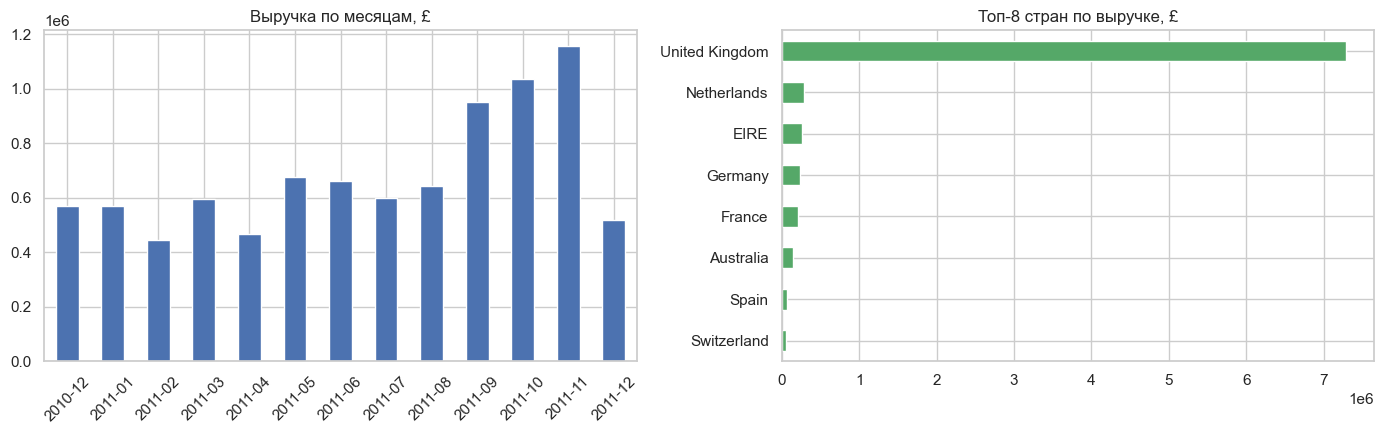

Доля Великобритании в выручке: 82.0%
Пик продаж: 2011-11 — предрождественский сезон


In [33]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))

monthly = d.set_index('InvoiceDate').resample('ME').agg(Revenue=('Revenue','sum'), Orders=('Invoice','nunique'))
monthly.index = monthly.index.strftime('%Y-%m')
monthly['Revenue'].plot(kind='bar', ax=ax[0], color='#4C72B0')
ax[0].set_title('Выручка по месяцам, £'); ax[0].set_xlabel('')
ax[0].tick_params(axis='x', rotation=45)

top_c = d.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(8)[::-1]
top_c.plot(kind='barh', ax=ax[1], color='#55A868')
ax[1].set_title('Топ-8 стран по выручке, £'); ax[1].set_ylabel('')
plt.tight_layout(); plt.show()

uk = d.loc[d.Country=='United Kingdom','Revenue'].sum()/d.Revenue.sum()
print(f'Доля Великобритании в выручке: {uk:.1%}')
print('Пик продаж:', monthly['Revenue'].idxmax(), '— предрождественский сезон')

## 4. Расчёт RFM-метрик
Для каждого клиента:
- **Recency** — дней с последней покупки;
- **Frequency** — число уникальных заказов;
- **Monetary** — суммарная выручка.

In [35]:
snapshot = d['InvoiceDate'].max().normalize() + pd.Timedelta(days=1)
print('Дата отсчёта:', snapshot.date())

rfm = d.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (snapshot - x.max()).days),
    Frequency=('Invoice', 'nunique'),
    Monetary=('Revenue', 'sum'),
)
rfm.describe(percentiles=[.25,.5,.75,.95,.99]).T

Дата отсчёта: 2011-12-10


,count,mean,std,min,25%,50%,75%,95%,99%,max
Recency,"4,338.00",92.06,100.01,0.00,17.00,50.00,141.75,311.00,368.63,373.00
Frequency,"4,338.00",4.27,7.70,1.00,1.00,2.00,5.00,13.00,30.00,209.00
Monetary,"4,338.00","2,048.69","8,985.23",3.75,306.48,668.57,"1,660.60","5,790.00","19,780.49","280,206.02"


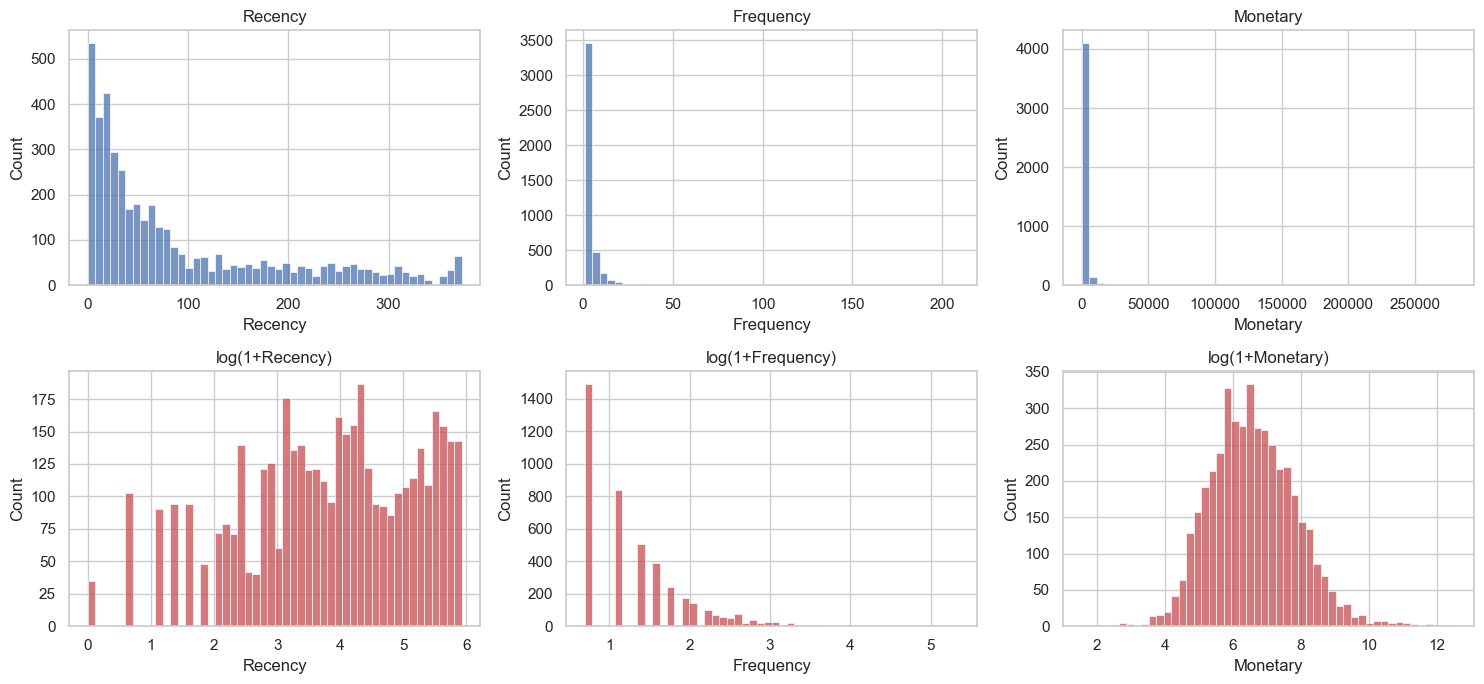

In [37]:
fig, ax = plt.subplots(2, 3, figsize=(15, 7))
for i, c in enumerate(['Recency','Frequency','Monetary']):
    sns.histplot(rfm[c], bins=50, ax=ax[0,i], color='#4C72B0'); ax[0,i].set_title(c)
    sns.histplot(np.log1p(rfm[c]), bins=50, ax=ax[1,i], color='#C44E52'); ax[1,i].set_title(f'log(1+{c})')
plt.tight_layout(); plt.show()

**Вывод:** Frequency и Monetary имеют очень сильный правый хвост: несколько клиентов-оптовиков покупают на сотни тысяч фунтов. После логарифмирования распределения становятся близки к нормальным - это пригодится для K-means.

## 5. RFM-скоринг и сегментация
Каждой метрике ставим балл от 1 до 5:
- **Recency** — квинтили, чем недавнее покупка, тем выше балл;
- **Monetary** — квинтили;
- **Frequency** — у многих клиентов одинаковое число заказов (1 заказ у ~34%), поэтому квинтили дали бы произвольное разбиение одинаковых значений. Используем фиксированные границы: 1, 2, 3, 4–6, 7+ заказов.

In [39]:
rfm['R'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1]).astype(int)
rfm['F'] = pd.cut(rfm['Frequency'], bins=[0,1,2,3,6,np.inf], labels=[1,2,3,4,5]).astype(int)
rfm['M'] = pd.qcut(rfm['Monetary'], 5, labels=[1,2,3,4,5]).astype(int)
rfm['RFM_Score'] = rfm['R'].astype(str) + rfm['F'].astype(str) + rfm['M'].astype(str)
rfm[['R','F','M']].apply(lambda s: s.value_counts().sort_index()).T

,1,2,3,4,5
R,861,866,863,880,868
F,1493,835,508,802,700
M,868,867,868,867,868


In [41]:
def segment(r, f):
    if r >= 4 and f >= 4: return 'Champions'
    if r <= 2 and f >= 4: return "Can't Lose Them"
    if r <= 2 and f == 3: return 'At Risk'
    if r <= 2:            return 'Hibernating'
    if r == 3:
        if f >= 4: return 'Loyal Customers'
        if f == 3: return 'Need Attention'
        return 'About to Sleep'
    if f == 3: return 'Loyal Customers'
    if f == 2: return 'Potential Loyalists'
    return 'New Customers' if r == 5 else 'Promising'

rfm['Segment'] = [segment(r, f) for r, f in zip(rfm['R'], rfm['F'])]

seg = rfm.groupby('Segment').agg(
    Customers=('Recency','size'),
    Recency=('Recency','mean'), Frequency=('Frequency','mean'),
    Monetary_avg=('Monetary','mean'), Revenue=('Monetary','sum'),
)
seg['Customers_%'] = seg['Customers'] / seg['Customers'].sum() * 100
seg['Revenue_%']   = seg['Revenue'] / seg['Revenue'].sum() * 100
seg = seg.sort_values('Revenue', ascending=False)
seg.round(1)

,Customers,Recency,Frequency,Monetary_avg,Revenue,Customers_%,Revenue_%
Segment,,,,,,,
Champions,1028,12.20,10.70,"5,602.40","5,759,220.80",23.70,64.80
Loyal Customers,469,34.90,4.90,"2,086.80","978,732.40",10.80,11.00
Hibernating,1335,208.10,1.30,510.80,"681,943.00",30.80,7.70
Can't Lose Them,210,128.90,5.50,"1,842.80","386,995.80",4.80,4.40
Potential Loyalists,279,15.40,2.00,"1,235.90","344,824.20",6.40,3.90
At Risk,182,142.90,3.00,"1,483.90","270,073.90",4.20,3.00
About to Sleep,478,52.00,1.40,519.80,"248,485.50",11.00,2.80
Need Attention,121,50.30,3.00,"1,163.20","140,750.70",2.80,1.60
Promising,169,23.10,1.00,314.10,"53,088.60",3.90,0.60


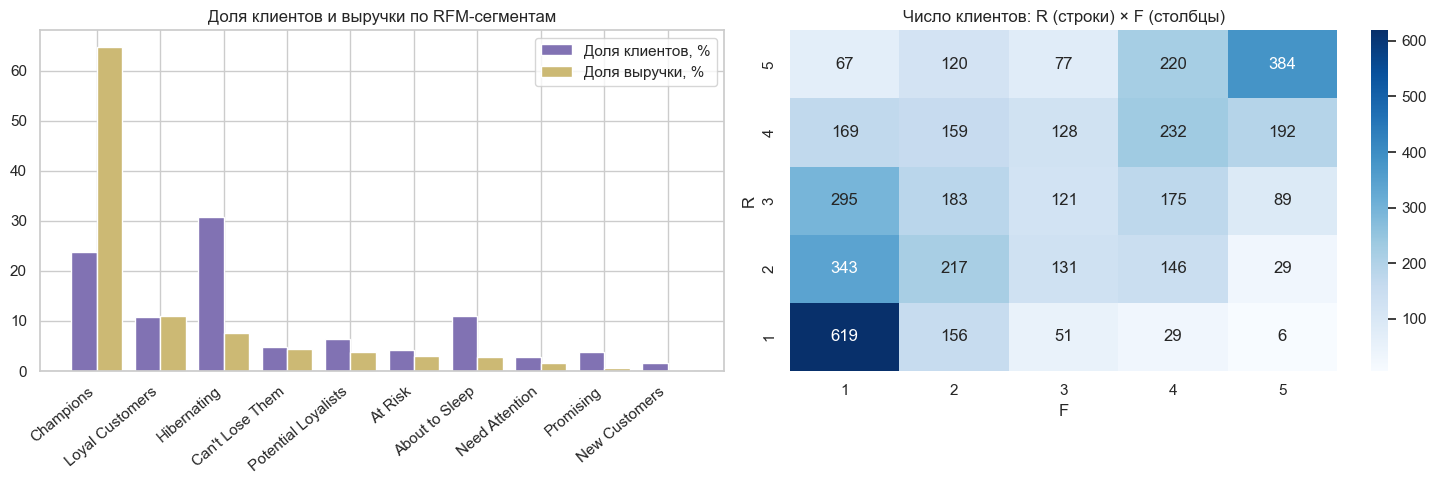

In [43]:
order = seg.index
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
x = np.arange(len(order)); w = 0.4
ax[0].bar(x-w/2, seg['Customers_%'], w, label='Доля клиентов, %', color='#8172B3')
ax[0].bar(x+w/2, seg['Revenue_%'],   w, label='Доля выручки, %',  color='#CCB974')
ax[0].set_xticks(x); ax[0].set_xticklabels(order, rotation=40, ha='right'); ax[0].legend()
ax[0].set_title('Доля клиентов и выручки по RFM-сегментам')

heat = rfm.pivot_table(index='R', columns='F', values='Monetary', aggfunc='size').sort_index(ascending=False)
sns.heatmap(heat, annot=True, fmt='.0f', cmap='Blues', ax=ax[1])
ax[1].set_title('Число клиентов: R (строки) × F (столбцы)')
plt.tight_layout(); plt.show()

In [45]:
top20 = rfm.sort_values('Monetary', ascending=False)
n20 = int(len(top20)*0.2)
print(f"Топ-20% клиентов приносят {top20['Monetary'].head(n20).sum()/top20['Monetary'].sum():.1%} выручки (принцип Парето)")

Топ-20% клиентов приносят 74.7% выручки (принцип Парето)


## 6. K-means кластеризация
1. **логарифмируем** - убираем влияние выбросов и сильной асимметрии;
2. **стандартизируем** - K-means считает евклидово расстояние и чувствителен к масштабу.

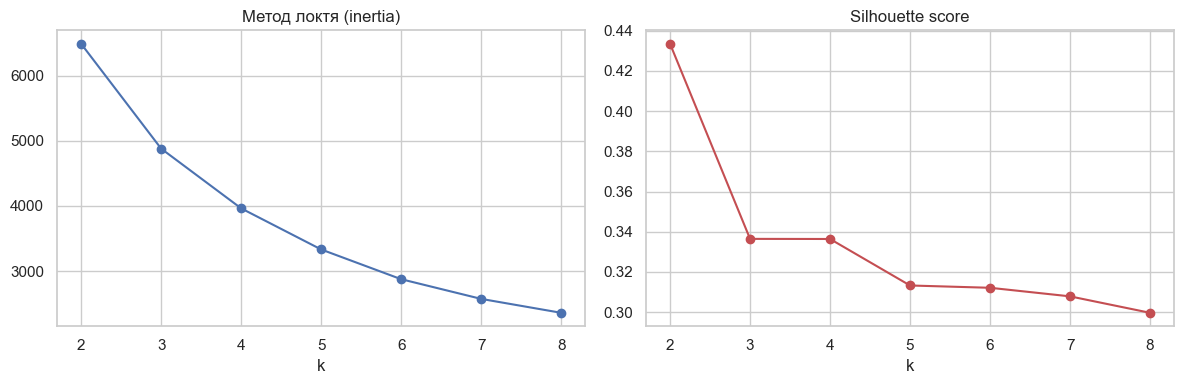

,k,inertia,silhouette
0,2,"6,487.98",0.43
1,3,"4,879.09",0.34
2,4,"3,962.72",0.34
3,5,"3,331.83",0.31
4,6,"2,875.39",0.31
5,7,"2,573.15",0.31
6,8,"2,359.54",0.30


In [47]:
X = np.log1p(rfm[['Recency','Frequency','Monetary']])
X_scaled = StandardScaler().fit_transform(X)

ks = range(2, 9)
inertia, sil = [], []
for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_scaled)
    inertia.append(km.inertia_)
    sil.append(silhouette_score(X_scaled, km.labels_, sample_size=3000, random_state=42))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(ks, inertia, 'o-'); ax[0].set_title('Метод локтя (inertia)'); ax[0].set_xlabel('k')
ax[1].plot(ks, sil, 'o-', color='#C44E52'); ax[1].set_title('Silhouette score'); ax[1].set_xlabel('k')
plt.tight_layout(); plt.show()
pd.DataFrame({'k': list(ks), 'inertia': inertia, 'silhouette': sil}).round(3)

**Выбор k.** Silhouette максимален при k = 2 («активные» и «неактивные» клиенты), но такое деление слишком грубое для маркетинга. Дальше значение почти не меняется (0,34 при k = 3 и 4), а локоть на графике выражен слабо. Выбираем **k = 4**: кластеры чётко различаются по профилю, и каждому можно назначить своё действие. 

In [49]:
K = 4
km = KMeans(n_clusters=K, random_state=42, n_init=10).fit(X_scaled)
rfm['Cluster'] = km.labels_

prof = rfm.groupby('Cluster').agg(
    Customers=('Recency','size'),
    Recency=('Recency','mean'), Frequency=('Frequency','mean'),
    Monetary_avg=('Monetary','mean'), Revenue=('Monetary','sum'),
)
prof['Customers_%'] = prof['Customers']/prof['Customers'].sum()*100
prof['Revenue_%']   = prof['Revenue']/prof['Revenue'].sum()*100
prof.round(1)

,Customers,Recency,Frequency,Monetary_avg,Revenue,Customers_%,Revenue_%
Cluster,,,,,,,
0,699,11.40,13.90,"8,194.30","5,727,810.00",16.10,64.40
1,1635,180.30,1.30,344.20,"562,832.90",37.70,6.30
2,826,17.30,2.20,555.80,"459,107.30",19.00,5.20
3,1178,70.00,4.10,"1,814.50","2,137,476.70",27.20,24.10


In [51]:
names = {0: 'Лучшие', 1: 'Потерянные', 2: 'Недавние, малоактивные', 3: 'Остывающие середняки'}
rfm['Cluster_name'] = rfm['Cluster'].map(names)
prof.insert(0, 'Name', prof.index.map(names))
prof.round(1)

,Name,Customers,Recency,Frequency,Monetary_avg,Revenue,Customers_%,Revenue_%
Cluster,,,,,,,,
0,Лучшие,699,11.40,13.90,"8,194.30","5,727,810.00",16.10,64.40
1,Потерянные,1635,180.30,1.30,344.20,"562,832.90",37.70,6.30
2,"Недавние, малоактивные",826,17.30,2.20,555.80,"459,107.30",19.00,5.20
3,Остывающие середняки,1178,70.00,4.10,"1,814.50","2,137,476.70",27.20,24.10


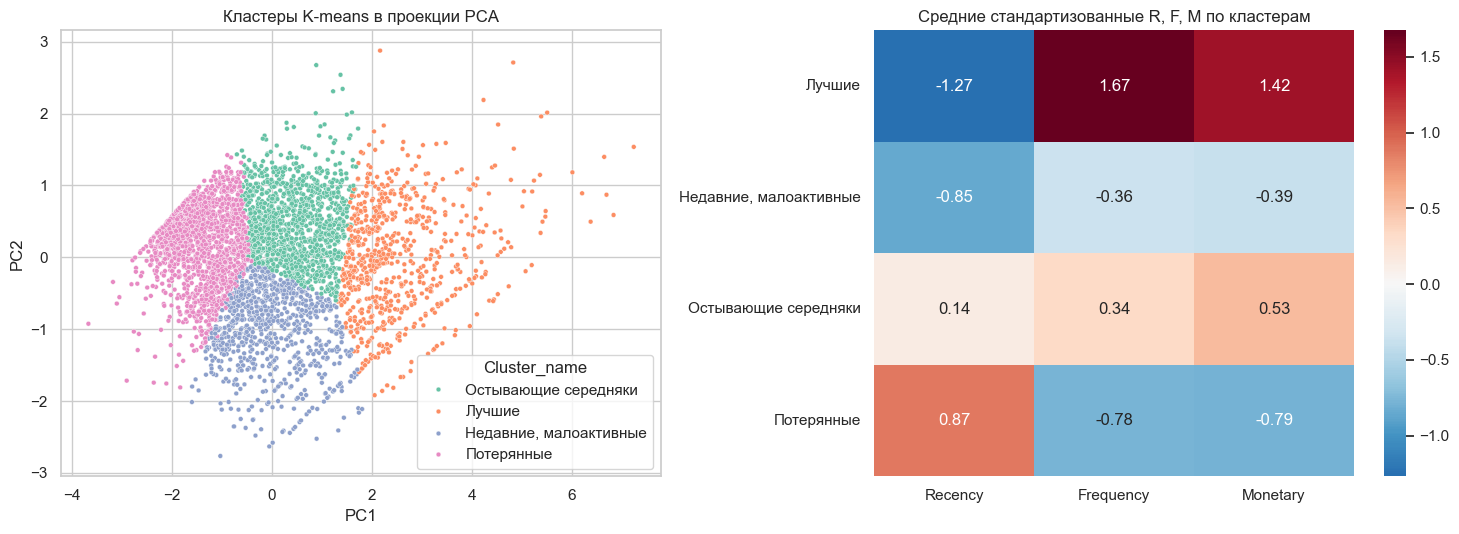

In [53]:
from sklearn.decomposition import PCA
pc = PCA(n_components=2, random_state=42).fit_transform(X_scaled)
fig, ax = plt.subplots(1, 2, figsize=(15, 5.5))
sns.scatterplot(x=pc[:,0], y=pc[:,1], hue=rfm['Cluster_name'], palette='Set2', s=12, ax=ax[0])
ax[0].set_title('Кластеры K-means в проекции PCA'); ax[0].set_xlabel('PC1'); ax[0].set_ylabel('PC2')

z = pd.DataFrame(X_scaled, columns=['Recency','Frequency','Monetary'], index=rfm.index)
z['Cluster_name'] = rfm['Cluster_name']
sns.heatmap(z.groupby('Cluster_name').mean(), annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax[1])
ax[1].set_title('Средние стандартизованные R, F, M по кластерам'); ax[1].set_ylabel('')
plt.tight_layout(); plt.show()

На тепловой карте красный цвет - значение выше среднего по базе, синий - ниже. Для Recency высокое значение - плохо.

## 7. Сравнение RFM-сегментов и кластеров K-means

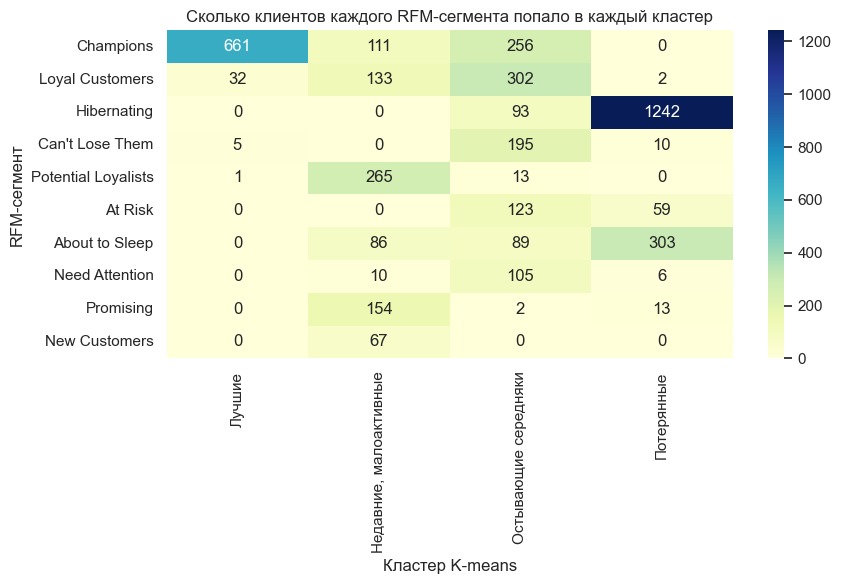

In [55]:
ct = pd.crosstab(rfm['Segment'], rfm['Cluster_name'])
plt.figure(figsize=(9, 6))
sns.heatmap(ct.loc[seg.index], annot=True, fmt='d', cmap='YlGnBu')
plt.title('Сколько клиентов каждого RFM-сегмента попало в каждый кластер'); plt.ylabel('RFM-сегмент'); plt.xlabel('Кластер K-means')
plt.tight_layout(); plt.show()

In [57]:
from sklearn.metrics import adjusted_rand_score
print(f"Adjusted Rand Index: {adjusted_rand_score(rfm['Segment'], rfm['Cluster']):.2f}")

Adjusted Rand Index: 0.44


Если сегменты RFM сконцентрированы в одном-двух кластерах, значит оба метода находят одну и ту же структуру. Расхождения показывают клиентов на границах - например, где пороговое правило RFM и группы K-means расходятся.

## 8. Выводы и рекомендации

In [59]:
champ = seg.loc['Champions']
print(f"Champions: {champ['Customers_%']:.1f}% клиентов дают {champ['Revenue_%']:.1f}% выручки")
risk = seg.loc[["Can't Lose Them", 'At Risk'] if "Can't Lose Them" in seg.index else ['At Risk']]
print(f"Can't Lose Them + At Risk: {risk['Customers_%'].sum():.1f}% клиентов, {risk['Revenue_%'].sum():.1f}% выручки — зона риска оттока")
hib = seg.loc['Hibernating']
print(f"Hibernating: {hib['Customers_%']:.1f}% клиентов, но только {hib['Revenue_%']:.1f}% выручки")

Champions: 23.7% клиентов дают 64.8% выручки
Can't Lose Them + At Risk: 9.0% клиентов, 7.4% выручки — зона риска оттока
Hibernating: 30.8% клиентов, но только 7.7% выручки


### Рекомендации по сегментам

| Сегмент | Действие | Метрика успеха |
| :--- | :--- | :--- |
| **Champions** | Это основа бизнеса, поэтому главная задача — не потерять их. Запускаем программу лояльности, даём первыми смотреть новинки, просим оставить отзыв и привести знакомых. Со скидками осторожнее: эти клиенты и так покупают, скидка просто уменьшит маржу. | Доля клиентов, которые купили снова в следующем квартале |
| **Loyal Customers** | Продаём больше того, что они уже берут: подборки по прошлым заказам, наборы к купленным товарам. | Рост среднего чека |
| **Potential Loyalists** и **Promising** | Задача — довести их до второго и третьего заказа. Небольшой бонус на следующую покупку и напоминание через пару недель после первой. | Доля тех, кто сделал второй и третий заказ |
| **New Customers** | После первой покупки отправляем короткую серию писем: рассказываем о магазине и показываем самые популярные товары. | Сколько человек вернулось в течение 30 дней |
| **Need Attention** и **About to Sleep** | Напоминаем о себе, предлагаем что-то сезонное, делаем акцию с конкретной датой окончания. | Сколько человек купило снова за 30–60 дней |
| **At Risk** | Персональное предложение и один короткий вопрос: почему перестали заказывать. | Сколько вернулось за 60 дней |
| **Can't Lose Them** | Таких клиентов всего 210, но каждый приносит в среднем около £1 800. Менеджеру стоит связаться с ними лично и обсудить условия. | Сколько выручки удалось сохранить |
| **Hibernating** | Самый большой сегмент, но денег от него немного. Много тратить не стоит: одна недорогая рассылка, а тем, кто не откликнулся, больше не писать в обычных кампаниях. | Стоимость одного контакта и окупилась ли рассылка |

### Ограничения анализа
- Период охватывает один год; сезонность влияет на Recency: клиенты, покупающие только к Рождеству, выглядят «спящими» в середине года.
- Данные заканчиваются 9 декабря 2011, последний месяц неполный.
- Анализ не учитывает категории товаров, маржинальность и каналы привлечения.
- Среди клиентов много оптовиков, поэтому Monetary сильно скошена; для них стоит делать отдельный анализ.
- Данные не показывают, какие акции сработают: для проверки рекомендаций нужны A/B-тесты.

## 9. Экспорт результатов

In [19]:
with pd.ExcelWriter('rfm_results.xlsx') as xl:
    rfm.reset_index().to_excel(xl, sheet_name='Customers', index=False)
    seg.reset_index().to_excel(xl, sheet_name='RFM_segments', index=False)
    prof.reset_index().to_excel(xl, sheet_name='KMeans_clusters', index=False)
    ct.reset_index().to_excel(xl, sheet_name='Segments_vs_clusters', index=False)

Сохранено: rfm_results.xlsx


In [82]:
d_final = d.merge(
    rfm[['Segment', 'Cluster_name']],
    left_on='CustomerID', right_index=True, how='left'
)
d_final

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country,Revenue,Segment,Cluster_name
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,Can't Lose Them,Лучшие
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,Can't Lose Them,Лучшие
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,Can't Lose Them,Лучшие
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,Can't Lose Them,Лучшие
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,Can't Lose Them,Лучшие
...,...,...,...,...,...,...,...,...,...,...,...
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680,France,12.60,Champions,"Недавние, малоактивные"
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680,France,16.60,Champions,"Недавние, малоактивные"
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680,France,16.60,Champions,"Недавние, малоактивные"
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680,France,14.85,Champions,"Недавние, малоактивные"
